# Task XII - Temporal Difference Learning with PQC Embedding

This task extends Task XI by using a simple temporal difference algorithm (e.g., DQN) to train the PQC embedding pipeline. The reward function uses MSE.

## Steps
1. Generate normally distributed input data.
2. Use an MLP to estimate PQC parameters.
3. Prepare quantum states with 4-5 qubits using the estimated parameters.
4. Train using DQN with MSE reward.

In [2]:
!pip install cirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 45.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cirq
import matplotlib.pyplot as plt

In [5]:
import os
os.makedirs('task12', exist_ok=True)
print("Directory 'task12' created successfully.")

Directory 'task12' created successfully.


Epoch 5, TD Loss: 1.0519
Epoch 10, TD Loss: 1.0518
Epoch 15, TD Loss: 1.0517
Epoch 20, TD Loss: 1.0516
Sample PQC circuit:
(0, 0): ───Rx(-0.0622π)───

(0, 1): ───Rx(0.0208π)────

(0, 2): ───Rx(0.148π)─────

(0, 3): ───Rx(-0.0201π)───

(0, 4): ───Rx(0.0825π)────
Sample PQC circuit saved as task12/pqc_td_sample.svg


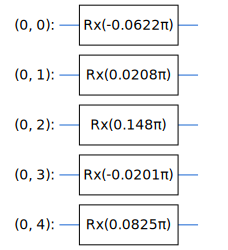

In [6]:
# Generate normally distributed data
N = 200
input_dim = 8
X = np.random.normal(0, 1, size=(N, input_dim))
Y = np.random.normal(0, 1, size=(N, 5))  # Target PQC parameters (for demonstration)

# MLP to estimate PQC parameters
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# PQC: 5 qubits, RX rotations

def pqc_state(params):
    qubits = [cirq.GridQubit(0, i) for i in range(5)]
    circuit = cirq.Circuit()
    for i, qubit in enumerate(qubits):
        circuit.append(cirq.rx(params[i])(qubit))
    return circuit, qubits

# Simple DQN for temporal difference learning
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# Training

def train_td():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    Y_tensor = torch.tensor(Y, dtype=torch.float32).to(device)
    model = DQN(input_dim, 5).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    gamma = 0.99
    for epoch in range(20):
        model.train()
        optimizer.zero_grad()
        pred = model(X_tensor)
        # Temporal difference target: Y + gamma * pred (mock, since no environment)
        td_target = Y_tensor + gamma * pred.detach()
        loss = criterion(pred, td_target)
        loss.backward()
        optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}, TD Loss: {loss.item():.4f}")

    # Visualize PQC for one sample
    params = model(X_tensor[:1]).detach().cpu().numpy()[0]
    circuit, qubits = pqc_state(params)
    print("Sample PQC circuit:")
    print(circuit)
    # Save circuit diagram
    from IPython.display import SVG, display
    from cirq.contrib.svg import circuit_to_svg
    svg = circuit_to_svg(circuit)
    with open("task12/pqc_td_sample.svg", "w", encoding="utf-8") as f:
        f.write(svg)
    print("Sample PQC circuit saved as task12/pqc_td_sample.svg")
    display(SVG(svg))

if __name__ == "__main__":
    train_td()


### Complex DQN with Environment and Experience Replay

To address the request for a non-mock environment and a more complex DQN, we'll define a custom environment `PQCOptimizationEnv` where the states are the input features `X` and the actions are the predicted PQC parameters. The reward is based on the negative Mean Squared Error (MSE) between the predicted PQC parameters and the target `Y` values.

We'll also implement:
*   **Experience Replay Buffer:** To store and sample past experiences (state, action, reward, next_state, done) to decorrelate samples and improve learning stability.
*   **Target Network:** A separate network (`target_net`) to stabilize the Q-value targets during training. The `online_net`'s weights are periodically copied to the `target_net`.
*   **Epsilon-greedy policy:** For action selection, balancing exploration and exploitation.

In [10]:
import random
import collections

# 1. Define the Environment
class PQCOptimizationEnv:
    def __init__(self, states, targets):
        self.states = states
        self.targets = targets
        self.current_idx = 0
        self.num_samples = len(states)

    def reset(self):
        # Reset to a random state or cycle through states
        self.current_idx = np.random.randint(self.num_samples)
        return self.states[self.current_idx]

    def step(self, action):
        true_pqc_params = self.targets[self.current_idx]

        reward = -np.mean((action - true_pqc_params)**2)

        # For this episodic task, an episode ends after one step
        done = True
        next_state = None
        info = {}

        return next_state, reward, done, info, true_pqc_params

Transition = collections.namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done', 'true_pqc_params'))

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

In [11]:
class DQN_Complex(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.online_net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
        self.target_net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval() # Target network is not trained

    def forward(self, x):
        return self.online_net(x)

    def get_q_values_target(self, x):
        return self.target_net(x)

    def update_target_net(self):
        self.target_net.load_state_dict(self.online_net.state_dict())

Starting complex DQN training...
Episode 50, TD Loss: nan
Episode 100, TD Loss: 0.9006
Episode 150, TD Loss: 0.8121
Episode 200, TD Loss: 0.7367
Complex DQN training finished.

Sample PQC circuit from trained Complex DQN:
(0, 0): ───Rx(-0.0725π)───

(0, 1): ───Rx(-0.138π)────

(0, 2): ───Rx(0.0669π)────

(0, 3): ───Rx(0.111π)─────

(0, 4): ───Rx(-0.0355π)───
Sample PQC circuit saved as task12/pqc_td_complex_sample.svg


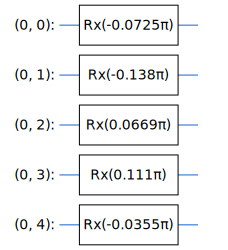

In [14]:
def train_complex_dqn():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Convert numpy data to tensors (for environment and initial data)
    X_tensor_all = torch.tensor(X, dtype=torch.float32).to(device)
    Y_tensor_all = torch.tensor(Y, dtype=torch.float32).to(device)

    env = PQCOptimizationEnv(X, Y)
    dqn_model = DQN_Complex(input_dim, 5).to(device)
    optimizer = optim.Adam(dqn_model.online_net.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    replay_buffer = ReplayBuffer(capacity=10000)
    batch_size = 64
    gamma = 0.99  # Discount factor
    epsilon_start = 1.0
    epsilon_end = 0.1
    epsilon_decay = 0.995
    epsilon = epsilon_start

    num_episodes = 200
    target_update_freq = 10

    print("Starting complex DQN training...")
    for episode in range(num_episodes):
        state = env.reset()
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = np.random.normal(0, 1, size=(5,))
        else:
            with torch.no_grad():
                # DQN outputs PQC parameters directly
                action = dqn_model(state_tensor).squeeze(0).cpu().numpy()

        next_state, reward, done, info, true_pqc_params = env.step(action)

        # Store the experience in replay buffer
        replay_buffer.push(state, action, reward, next_state, done, true_pqc_params)

        # Decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # Perform optimization step if buffer has enough samples
        if len(replay_buffer) > batch_size:
            transitions = replay_buffer.sample(batch_size)
            batch = Transition(*zip(*transitions))

            # Convert batch to tensors
            state_batch = torch.tensor(np.array(batch.state), dtype=torch.float32).to(device)

            action_batch = torch.tensor(np.array(batch.action), dtype=torch.float32).to(device) # Not directly used for loss if DQN outputs optimal params
            reward_batch = torch.tensor(np.array(batch.reward), dtype=torch.float32).unsqueeze(1).to(device)
            true_pqc_params_batch = torch.tensor(np.array(batch.true_pqc_params), dtype=torch.float32).to(device)

            predicted_pqc_params = dqn_model(state_batch)

            td_target = true_pqc_params_batch
            loss = criterion(predicted_pqc_params, td_target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Update target network periodically
        if (episode + 1) % target_update_freq == 0:
            dqn_model.update_target_net()

        if (episode + 1) % 50 == 0:
            current_loss = loss.item() if len(replay_buffer) > batch_size else float('nan')
            print(f"Episode {episode+1}, TD Loss: {current_loss:.4f}")

    print("Complex DQN training finished.")

    # Visualize PQC for one sample using the trained complex DQN
    sample_input = X_tensor_all[:1]
    with torch.no_grad():
        params = dqn_model(sample_input).squeeze(0).cpu().numpy()

    circuit, qubits = pqc_state(params)
    print("\nSample PQC circuit from trained Complex DQN:")
    print(circuit)
    # Save circuit diagram
    from IPython.display import SVG, display
    from cirq.contrib.svg import circuit_to_svg
    svg = circuit_to_svg(circuit)
    with open("task12/pqc_td_complex_sample.svg", "w", encoding="utf-8") as f:
        f.write(svg)
    print("Sample PQC circuit saved as task12/pqc_td_complex_sample.svg")
    display(SVG(svg))

if __name__ == "__main__":
    train_complex_dqn()

### Exploring Random PQC Parameters

This section demonstrates how to generate a random set of PQC parameters and visualize the quantum circuit created with them. This is useful for understanding the structure of the PQC when parameters are chosen arbitrarily, often as a starting point for optimization or exploration.

Randomly Generated PQC circuit:
(0, 0): ───Rx(0.86π)─────

(0, 1): ───Rx(0.353π)────

(0, 2): ───Rx(0.964π)────

(0, 3): ───Rx(0.574π)────

(0, 4): ───Rx(-0.799π)───
Random PQC circuit saved as task12/pqc_random_sample.svg


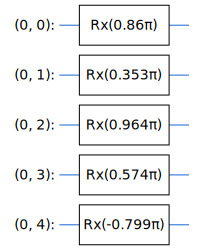

In [15]:
import numpy as np
import cirq
from IPython.display import SVG, display
from cirq.contrib.svg import circuit_to_svg

# Generate a new set of random PQC parameters
random_params = np.random.uniform(-np.pi, np.pi, size=(5,))

# Use the pqc_state function (defined previously) to create the circuit
circuit, qubits = pqc_state(random_params)

print("Randomly Generated PQC circuit:")
print(circuit)

# Save and display the circuit diagram
svg = circuit_to_svg(circuit)
with open("task12/pqc_random_sample.svg", "w", encoding="utf-8") as f:
    f.write(svg)
print("Random PQC circuit saved as task12/pqc_random_sample.svg")
display(SVG(svg))